In [181]:
import numpy as np 
import pandas as pd 
import os 
import matplotlib.pyplot as plt
def load_kaggle_data(filename, dataset_slug):
    """
    Automatically detects the environment and loads a CSV file 
    using either the local path or the Kaggle server path.
    
    Parameters:
    - filename (str): The name of the file (e.g., 'patients.csv')
    - dataset_slug (str): The dataset folder name used on Kaggle (e.g., 'username/dataset_name')
    """

    kaggle_path = os.path.join('/kaggle/input/datasets/', dataset_slug, filename)
  
    if os.path.exists(kaggle_path):
        print(f"✈️ Running on Kaggle. Loading: {kaggle_path}")
        return pd.read_csv(kaggle_path)
    else:
        print(f"🏠 Running locally. Loading: {filename}")
        return pd.read_csv('../data/'+filename)

data = load_kaggle_data("Expanded_data_with_more_features.csv","desalegngeb/students-exam-scores")

🏠 Running locally. Loading: Expanded_data_with_more_features.csv


In [182]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  str    
 2   EthnicGroup          28801 non-null  str    
 3   ParentEduc           28796 non-null  str    
 4   LunchType            30641 non-null  str    
 5   TestPrep             28811 non-null  str    
 6   ParentMaritalStatus  29451 non-null  str    
 7   PracticeSport        30010 non-null  str    
 8   IsFirstChild         29737 non-null  str    
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  str    
 11  WklyStudyHours       29686 non-null  str    
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), str(10)
memory usage: 

In [183]:
data.shape

(30641, 15)

```
# Data Dictionary (column description)

Gender: Gender of the student (male/female)
EthnicGroup: Ethnic group of the student (group A to E)
ParentEduc: Parent(s) education background (from some_highschool to master's degree)
LunchType: School lunch type (standard or free/reduced)
TestPrep: Test preparation course followed (completed or none)
ParentMaritalStatus: Parent(s) marital status (married/single/widowed/divorced)
PracticeSport: How often the student parctice sport (never/sometimes/regularly))
IsFirstChild: If the child is first child in the family or not (yes/no)
NrSiblings: Number of siblings the student has (0 to 7)
TransportMeans: Means of transport to school (schoolbus/private)
WklyStudyHours: Weekly self-study hours(less that 5hrs; between 5 and 10hrs; more than 10hrs)
MathScore: math test score(0-100)
ReadingScore: reading test score(0-100)
WritingScore: writing test score(0-100)
Analytics questions:

What factors (features) affect test scores most?
Are there interacting features which affect test scores?
```

In [184]:
data = data.dropna().reset_index(drop=True)
data.isnull().sum().sort_values(ascending=False)

Unnamed: 0             0
Gender                 0
EthnicGroup            0
ParentEduc             0
LunchType              0
TestPrep               0
ParentMaritalStatus    0
PracticeSport          0
IsFirstChild           0
NrSiblings             0
TransportMeans         0
WklyStudyHours         0
MathScore              0
ReadingScore           0
WritingScore           0
dtype: int64

In [185]:
score_columns = ["MathScore", "ReadingScore", "WritingScore"]
data["AverageScore"] = data[score_columns].mean(axis=1)
data["ScoreIndicator"] = pd.cut(
    data["AverageScore"],
    bins=[0, 60, 70, 80, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"],
    include_lowest=True,
)
data = data.drop(columns=score_columns)

data[["AverageScore", "ScoreIndicator"]].head()

,AverageScore,ScoreIndicator
0,90.333333,Excellent
1,76.333333,Good
2,78.666667,Good
3,89.000000,Excellent
4,41.000000,Needs Improvement


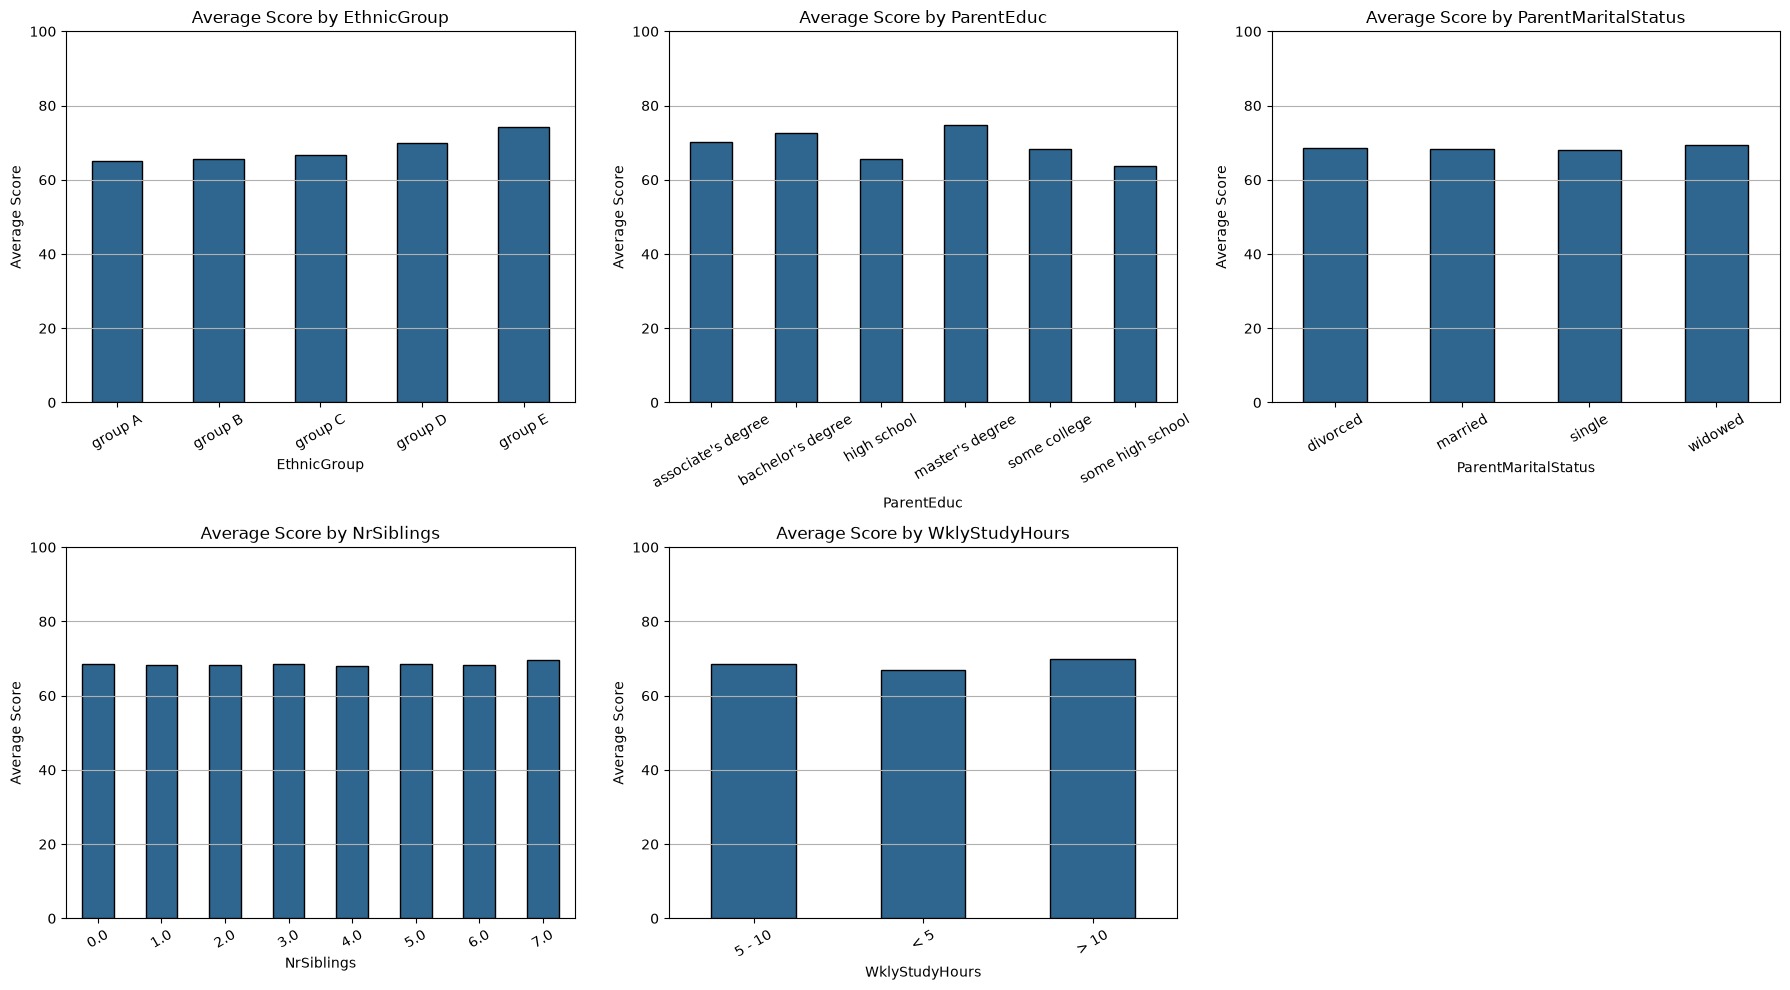

In [186]:
grouping_columns = [
    "EthnicGroup",
    "ParentEduc",
    "ParentMaritalStatus",
    "NrSiblings",
    "WklyStudyHours",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for axis, grouping_column in zip(axes, grouping_columns):
    grouped_scores = data.groupby(grouping_column, observed=False)["AverageScore"].mean()
    grouped_scores.plot(
        kind="bar",
        ax=axis,
        color="#2f6690",
        edgecolor="black",
    )
    axis.set_title(f"Average Score by {grouping_column}")
    axis.set_xlabel(grouping_column)
    axis.set_ylabel("Average Score")
    axis.set_ylim(0, 100)
    axis.tick_params(axis="x", rotation=30)
    axis.grid(axis="y")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

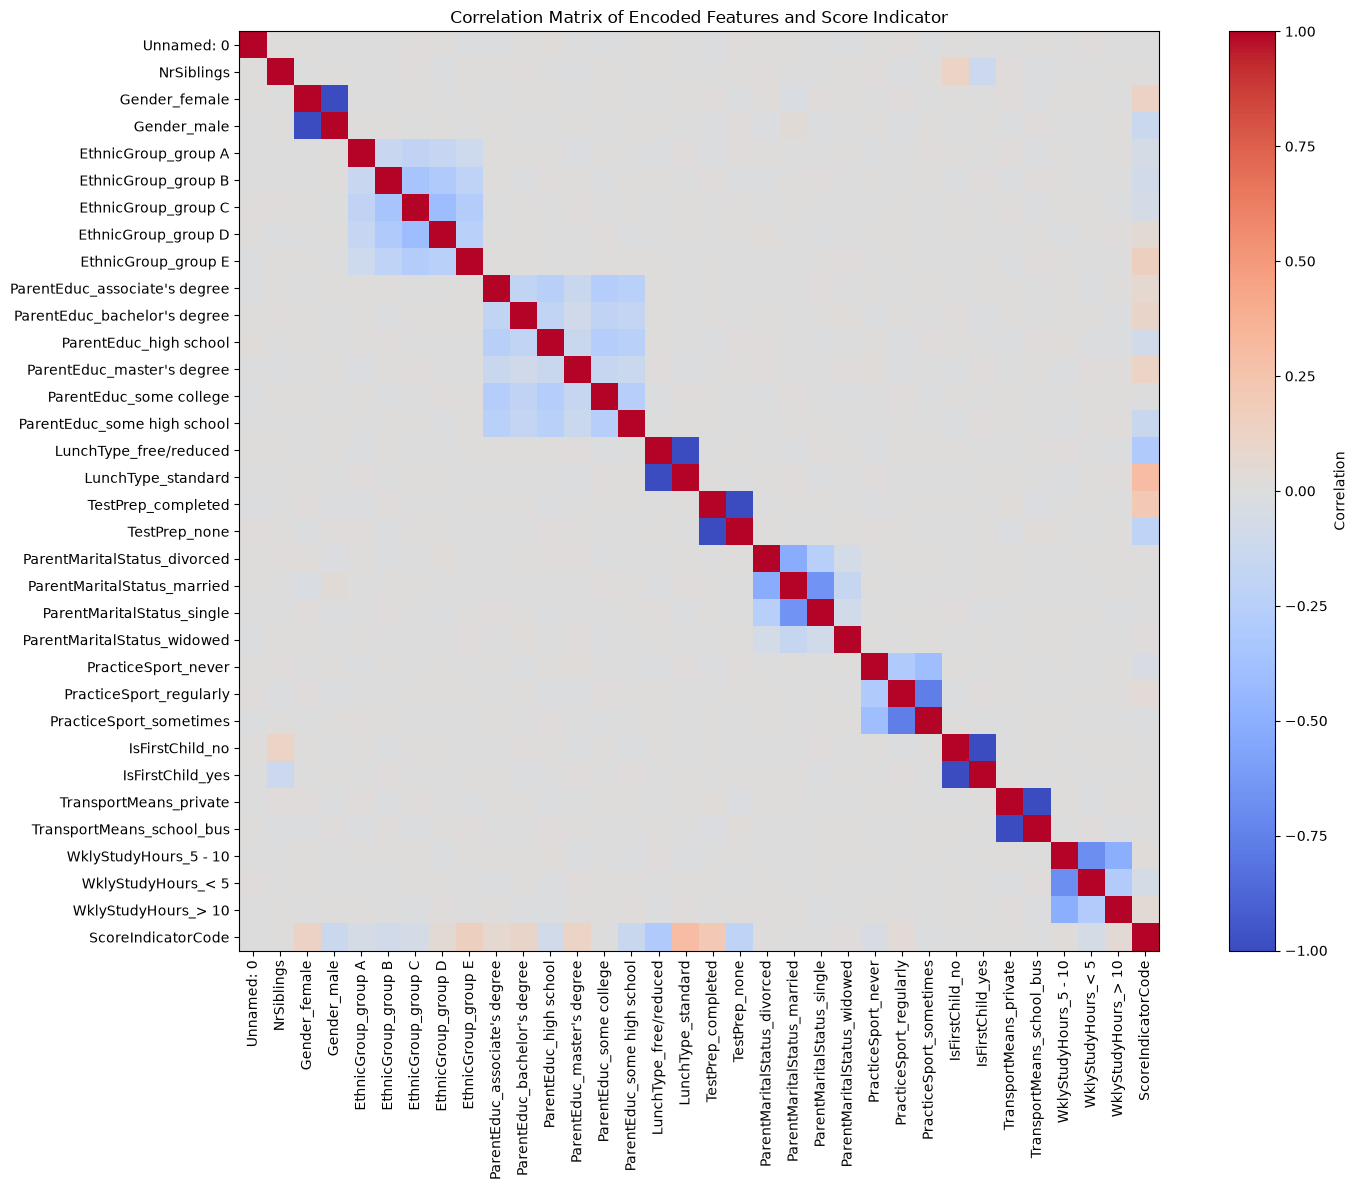

ScoreIndicatorCode               1.000000
LunchType_standard               0.292805
TestPrep_completed               0.210063
EthnicGroup_group E              0.154166
Gender_female                    0.126334
ParentEduc_master's degree       0.121654
ParentEduc_bachelor's degree     0.108541
ParentEduc_associate's degree    0.058987
EthnicGroup_group D              0.053904
WklyStudyHours_> 10              0.045189
PracticeSport_regularly          0.035253
WklyStudyHours_5 - 10            0.017528
ParentMaritalStatus_widowed      0.015220
ParentMaritalStatus_divorced     0.006657
NrSiblings                       0.006287
TransportMeans_private           0.003637
IsFirstChild_yes                 0.003429
Unnamed: 0                       0.001998
IsFirstChild_no                  0.003429
TransportMeans_school_bus        0.003637
ParentMaritalStatus_married      0.004847
ParentMaritalStatus_single       0.005126
ParentEduc_some college          0.005183
PracticeSport_sometimes          0

In [187]:
feature_data = data.drop(columns=["ScoreIndicator", "AverageScore"])
categorical_columns = feature_data.select_dtypes(
    include=["object", "string", "category"]
).columns
encoded_data = pd.get_dummies(
    feature_data,
    columns=categorical_columns,
    dtype=int,
)
encoded_data["ScoreIndicatorCode"] = data["ScoreIndicator"].cat.codes
correlation_matrix = encoded_data.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix of Encoded Features and Score Indicator")
plt.tight_layout()
plt.show()

correlation_matrix["ScoreIndicatorCode"].sort_values(ascending=False).abs()

In [188]:
encoded_data.head()

,Unnamed: 0,NrSiblings,Gender_female,Gender_male,EthnicGroup_group A,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,ParentEduc_associate's degree,...,PracticeSport_regularly,PracticeSport_sometimes,IsFirstChild_no,IsFirstChild_yes,TransportMeans_private,TransportMeans_school_bus,WklyStudyHours_5 - 10,WklyStudyHours_< 5,WklyStudyHours_> 10,ScoreIndicatorCode
0,2,4.0,1,0,0,1,0,0,0,0,...,0,1,0,1,0,1,0,1,0,3
1,4,0.0,0,1,0,0,1,0,0,0,...,0,1,0,1,0,1,1,0,0,2
2,5,1.0,1,0,0,1,0,0,0,1,...,1,0,0,1,0,1,1,0,0,2
3,6,1.0,1,0,0,1,0,0,0,0,...,0,0,1,0,1,0,1,0,0,3
4,7,1.0,0,1,0,1,0,0,0,0,...,0,1,0,1,1,0,0,0,1,0


In [189]:
target_correlations = correlation_matrix["ScoreIndicatorCode"].drop("ScoreIndicatorCode")
top_10_features = target_correlations.abs().sort_values(ascending=False).head(10).index

X = encoded_data[top_10_features]
y = data["ScoreIndicator"]

print("Selected features:")
print(list(top_10_features))
print(f"Feature matrix shape: {X.shape}")
print(f"Target classes: {list(y.cat.categories)}")

Selected features:
['LunchType_standard', 'LunchType_free/reduced', 'TestPrep_none', 'TestPrep_completed', 'EthnicGroup_group E', 'ParentEduc_some high school', 'Gender_female', 'Gender_male', "ParentEduc_master's degree", "ParentEduc_bachelor's degree"]
Feature matrix shape: (19243, 10)
Target classes: ['Needs Improvement', 'Average', 'Good', 'Excellent']


In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

classifier = RandomForestClassifier(
    n_estimators=75,
    random_state=42,
    class_weight="balanced",
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [191]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

                   precision    recall  f1-score   support

          Average       0.28      0.08      0.12      1471
        Excellent       0.41      0.60      0.48      1277
             Good       0.25      0.17      0.20      1342
Needs Improvement       0.46      0.69      0.55      1683

         accuracy                           0.39      5773
        macro avg       0.35      0.38      0.34      5773
     weighted avg       0.35      0.39      0.35      5773



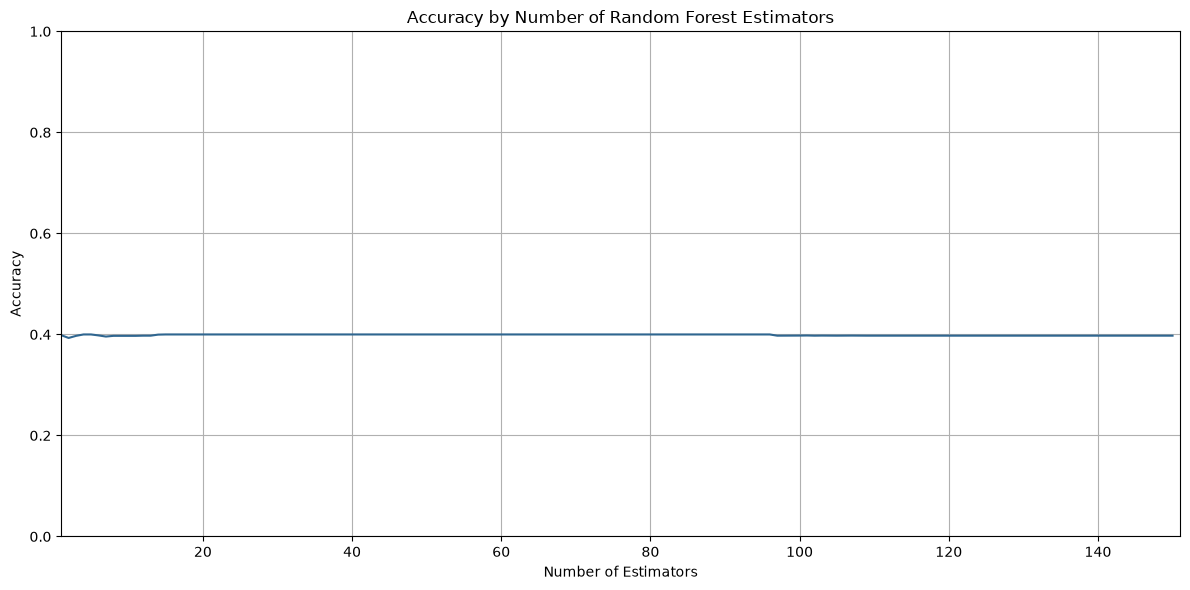

Best n_estimators: 17
Best accuracy: 0.400


In [192]:
from sklearn.metrics import accuracy_score

n_estimators_values = range(1, 151)
accuracy_values = []

forest = RandomForestClassifier(
    n_estimators=1,
    warm_start=True,
    random_state=42,
)

for n_estimators in n_estimators_values:
    forest.set_params(n_estimators=n_estimators)
    forest.fit(X_train, y_train)
    predictions = forest.predict(X_test)
    accuracy_values.append(accuracy_score(y_test, predictions))

plt.figure(figsize=(12, 6))
plt.plot(n_estimators_values, accuracy_values, color="#2f6690")
plt.title("Accuracy by Number of Random Forest Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.xlim(1, 151)
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

best_index = int(np.argmax(accuracy_values))
print(f"Best n_estimators: {best_index + 1}")
print(f"Best accuracy: {accuracy_values[best_index]:.3f}")

In [193]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

classifier = RandomForestClassifier(
    n_estimators=17,
    random_state=42,
    class_weight="balanced",
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [194]:
print(classification_report(y_test,y_pred))

                   precision    recall  f1-score   support

          Average       0.27      0.08      0.13      1471
        Excellent       0.41      0.60      0.48      1277
             Good       0.24      0.16      0.19      1342
Needs Improvement       0.46      0.69      0.55      1683

         accuracy                           0.39      5773
        macro avg       0.34      0.38      0.34      5773
     weighted avg       0.35      0.39      0.34      5773

